In [1]:
!pip install ultralytics datasets huggingface_hub


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 35.8 MB/s eta 0:00:00


In [ ]:
from datasets import load_dataset
from huggingface_hub import snapshot_download
from huggingface_hub import login
from getpass import getpass
#github no permite versionar el archivo si tiene tokens (x defecto tiene activado política de Push Protection y Secret Scanning)
token_sololectura = getpass("Introduce tu token de Hugging Face: ")
login(token=token_sololectura)
repo_path = snapshot_download("YashJain/UI-Elements-Detection-Dataset", repo_type="dataset")
print("Dataset descargado en:", repo_path)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Fetching 3787 files:   0%|          | 0/3787 [00:00<?, ?it/s]

Dataset descargado en: /root/.cache/huggingface/hub/datasets--YashJain--UI-Elements-Detection-Dataset/snapshots/0adda54cdc45cb8960b4e75580f78aad40fbcc3c


In [2]:
# 1. Montar Google Drive para usar el dataset desde ahi
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
repo_path = "/content/drive/MyDrive/MIA/Dataset"

In [4]:
print("Dataset descargado en:", repo_path)

Dataset descargado en: /content/drive/MyDrive/MIA/Dataset


In [ ]:
import os

yaml_content = f"""
train: {repo_path}/train/images
val: {repo_path}/val/images
test: {repo_path}/test/images
names:
  0: link
  1: button
  2: input
  3: select
  4: textarea
  5: label
  6: checkbox
  7: radio
  8: dropdown
  9: slider
  10: toggle
  11: menu_item
  12: clickable
  13: icon
  14: image
  15: text
nc: 16
"""

with open("data.yaml", "w") as f:
    f.write(yaml_content)

print("✅ Archivo data.yaml creado en", os.getcwd())

✅ Archivo data.yaml creado en /content


In [5]:
#ENTRENAMIENTO YOLO V8
from ultralytics import YOLO
# Cargar modelo base
model = YOLO("yolov8n.pt")  # tambien se puede usar yolov8s.pt, yolov8m.pt
# Entrenar
model.train(
    data="/content/drive/MyDrive/MIA/Dataset/dataset.yaml",
    epochs=50,
    imgsz=640, #se probó con 1920 y la sesión falló porque se usó toda la Ram disponible, por ese motivo le cambie a 640
    batch=16,
    workers=2
)

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.3.203 🚀 Python-3.12.11 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/MIA/Dataset/dataset.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=Fals

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([ 0,  1,  2,  4,  5,  7,  8,  9, 11, 12, 13])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7c0bbfdf5940>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.

In [6]:
metrics = model.val()
print(metrics)

Ultralytics 8.3.203 🚀 Python-3.12.11 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
Model summary (fused): 72 layers, 3,008,768 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.3±0.1 ms, read: 240.4±138.1 MB/s, size: 698.3 KB)
val: Scanning /content/drive/MyDrive/MIA/Dataset/val/labels.cache... 71 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 71/71 139.4Kit/s 0.0s
val: /content/drive/MyDrive/MIA/Dataset/val/images/dev_tools_jsfiddle.net_1729629915.png: 5 duplicate labels removed
val: /content/drive/MyDrive/MIA/Dataset/val/images/development_developer.mozilla.org_1729626875.png: 3 duplicate labels removed
val: /content/drive/MyDrive/MIA/Dataset/val/images/development_developer.mozilla.org_1729629644.png: 3 duplicate labels removed
val: /content/drive/MyDrive/MIA/Dataset/val/images/e_commerce_www.amazon.com_1729629595.png: 4 duplicate labels removed
val: /content/drive/MyDrive/MIA/Dataset/val/images/microsoft_office_www.office.com_1729629719.png: 1 duplicate lab


image 1/1 /content/drive/MyDrive/MIA/Dataset/test/images/microsoft_office_support.microsoft.com_1729629743.png: 320x640 19 links, 9 buttons, 2 inputs, 6.0ms
Speed: 1.9ms preprocess, 6.0ms inference, 1.4ms postprocess per image at shape (1, 3, 320, 640)
Results saved to /content/runs/detect/train4


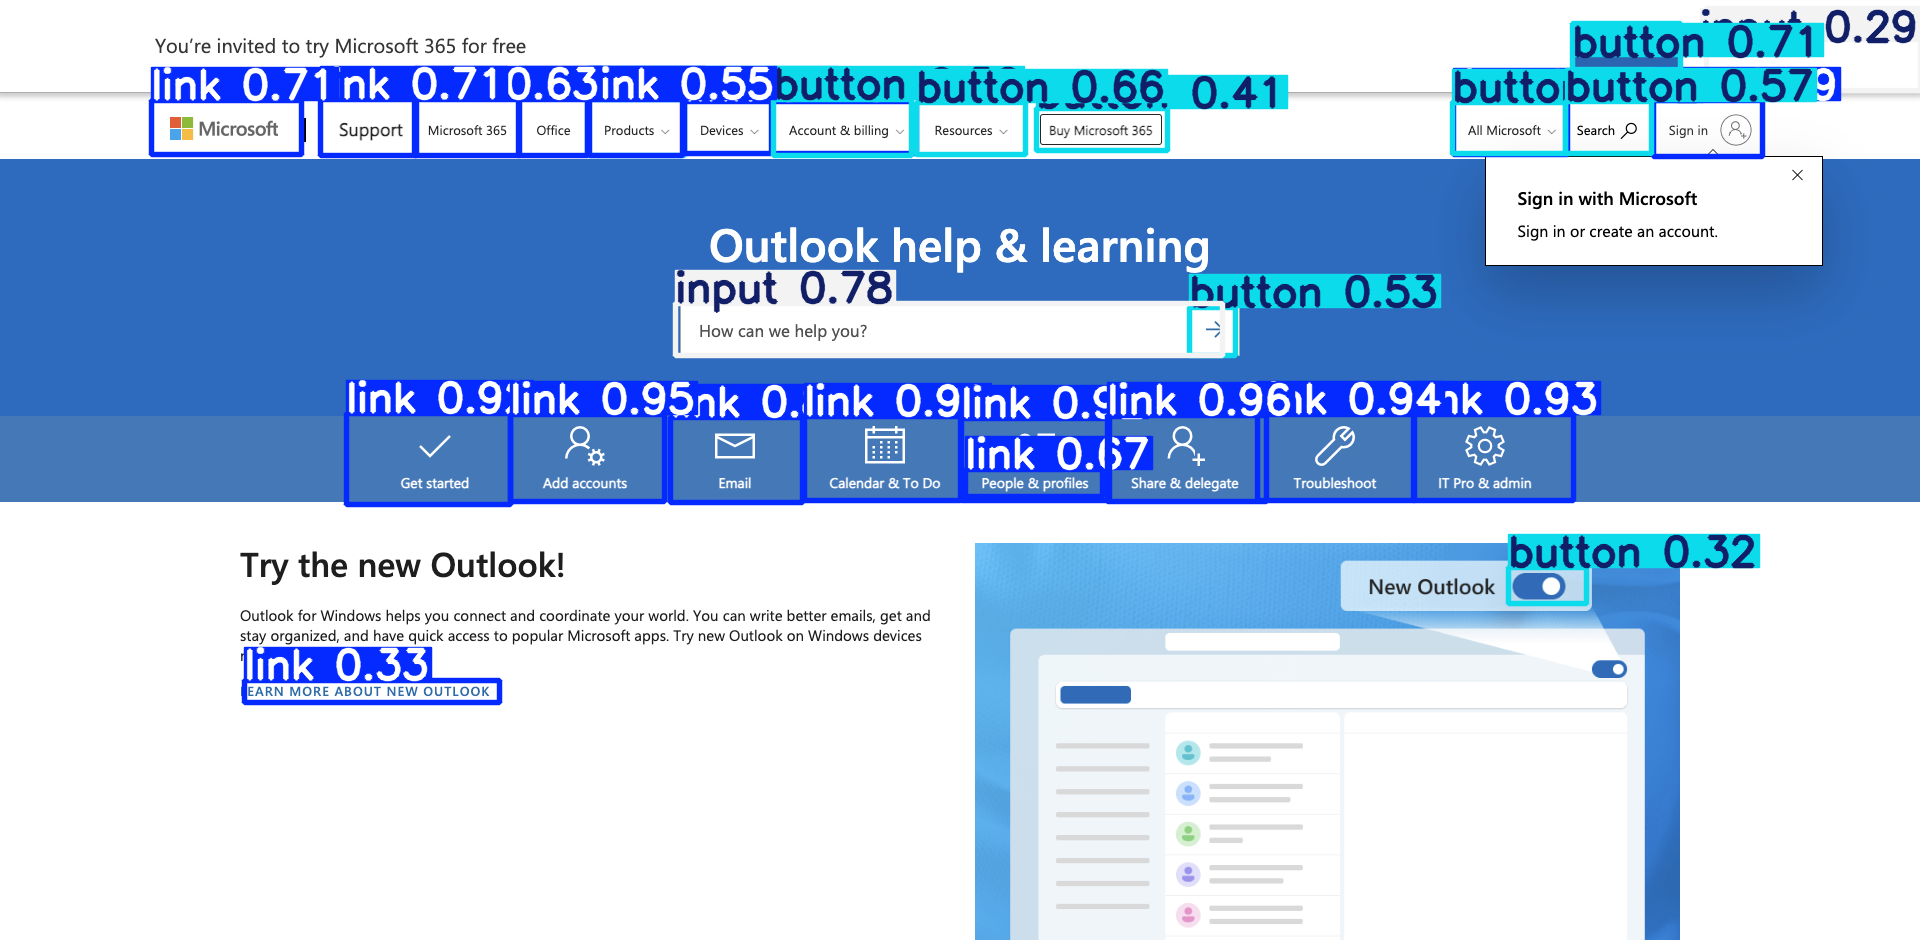

ultralytics.engine.results.Results object with attributes:

boxes: ultralytics.engine.results.Boxes object
keypoints: None
masks: None
names: {0: 'link', 1: 'button', 2: 'input', 3: 'select', 4: 'textarea', 5: 'label', 6: 'checkbox', 7: 'radio', 8: 'dropdown', 9: 'slider', 10: 'toggle', 11: 'menu_item', 12: 'clickable', 13: 'icon', 14: 'image', 15: 'text'}
obb: None
orig_img: array([[[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       ...,

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],


In [9]:
import random
import os

test_img_dir = os.path.join(repo_path, "test/images")
test_img = os.path.join(test_img_dir, random.choice(os.listdir(test_img_dir)))

results = model(test_img, save=True, conf=0.25)
res = results[0] if isinstance(results, list) else results
res.show()
print(res)


In [10]:
from google.colab import files

# Descargar el modelo entrenado
files.download("runs/detect/train/weights/best.pt")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [11]:
#EVALUAR METRICAS
results = model.val(data="/content/drive/MyDrive/MIA/Dataset/dataset.yaml")
print(results)  # muestra mAP, precisión, recall

Ultralytics 8.3.203 🚀 Python-3.12.11 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
val: Fast image access ✅ (ping: 0.4±0.1 ms, read: 152.9±109.7 MB/s, size: 410.2 KB)
val: Scanning /content/drive/MyDrive/MIA/Dataset/val/labels.cache... 71 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 71/71 138.6Kit/s 0.0s
val: /content/drive/MyDrive/MIA/Dataset/val/images/dev_tools_jsfiddle.net_1729629915.png: 5 duplicate labels removed
val: /content/drive/MyDrive/MIA/Dataset/val/images/development_developer.mozilla.org_1729626875.png: 3 duplicate labels removed
val: /content/drive/MyDrive/MIA/Dataset/val/images/development_developer.mozilla.org_1729629644.png: 3 duplicate labels removed
val: /content/drive/MyDrive/MIA/Dataset/val/images/e_commerce_www.amazon.com_1729629595.png: 4 duplicate labels removed
val: /content/drive/MyDrive/MIA/Dataset/val/images/microsoft_office_www.office.com_1729629719.png: 1 duplicate labels removed
val: /content/drive/MyDrive/MIA/Dataset/val/images/mostvisited_amazo

                             0
metrics/precision(B)  0.372843
metrics/recall(B)     0.139809
metrics/mAP50(B)      0.145393
metrics/mAP50-95(B)   0.101833
fitness               0.101833


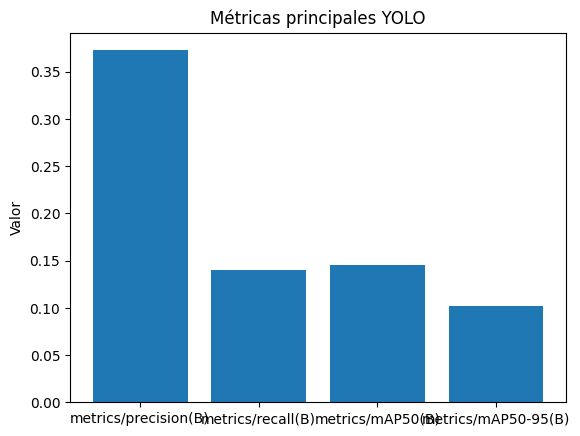

In [12]:
import pandas as pd
import matplotlib.pyplot as plt

# convertir resultados a DataFrame
df = pd.DataFrame([results.results_dict])
print(df.T)  # mostrar métricas en tabla

# graficar mAP y precisión
metrics = ["metrics/precision(B)", "metrics/recall(B)", "metrics/mAP50(B)", "metrics/mAP50-95(B)"]
valores = [df[m].values[0] for m in metrics]

plt.bar(metrics, valores)
plt.ylabel("Valor")
plt.title("Métricas principales YOLO")
plt.show()

In [13]:
import shutil
# Comprimir la carpeta en un zip
shutil.make_archive("/content/train5", 'zip', "/content/runs/detect/train5")

# Descargar el zip
from google.colab import files
files.download("/content/train5.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

**📊 Métricas**

Precision (0.37 ≈ 37%)
De todas las predicciones que el modelo hace como positivas, solo el 37% son correctas.
👉 Hay bastantes falsos positivos.

Recall (0.14 ≈ 14%)
El modelo solo detecta el 14% de los objetos que realmente existen en las imágenes.
👉 Muy bajo, significa que está “dejando pasar” la mayoría de los objetos (muchos falsos negativos).

mAP@50 (0.15 ≈ 15%)
Media de precisión promedio cuando el IoU ≥ 0.5.
👉 Muy bajo. Lo ideal en un modelo decente suele ser >50%.

mAP@50-95 (0.10 ≈ 10%)
Más exigente (considera IoU de 0.5 a 0.95).
👉 Muy bajo, indica que el modelo no está localizando los objetos con precisión en las cajas.

Fitness (0.10)
Es una métrica interna usada en YOLO (combinación de mAP y recall).
👉 También refleja un rendimiento bastante flojo.

**⚠️ Interpretación**
Estos resultados indican que el modelo casi no está detectando nada:

Encuentra muy pocos objetos (bajo recall).

Los que detecta, muchas veces son incorrectos (precision medio-bajo).

El mAP es bajo, lo que confirma que no está generalizando.

**🔧 Posibles causas y qué hacer**

Cantidad de datos

¿Cuántas imágenes tienes para entrenar? Con pocas   (<1000) es difícil que YOLO aprenda bien.

Aumentar dataset o usar data augmentation (hsv_h, scale, flipud, fliplr, etc.).

Distribución de clases

Puede que algunas clases casi no aparezcan en tu dataset.

Revisar el balance de etiquetas.

Número de épocas

¿Cuántas epochs usaste? Con 50 puede quedarse corto. Prueba con 100–300 (especialmente si usas yolov8n o yolov8s).

Tamaño de modelo

yolov8n.pt es muy pequeño (rápido pero débil).

Si tienes recursos, prueba yolov8m.pt o yolov8l.pt.

Etiquetas inconsistentes

El error de clases que viste antes sugiere que podría haber anotaciones mal hechas.

Revisa visualmente tus cajas (model.train(..., plots=True)) para ver si coinciden.